In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# =========================================================
# Device
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(1234)
np.random.seed(1234)

# =========================================================
# Exact solution and problem data
# =========================================================
def exact_u(x, y):
    return 0.5 * x * y**2

def kappa(x, y):
    return 2.0 * x

def f_rhs(x, y):
    return -y**2 - 2.0 * x**2

# =========================================================
# PINN model: 2 hidden layers, 16 neurons each, tanh
# =========================================================
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.net(inp)

model = PINN().to(device)

# =========================================================
# Sampling points
# =========================================================
def sample_interior(n):
    x = torch.rand(n, 1, device=device, requires_grad=True)
    y = torch.rand(n, 1, device=device, requires_grad=True)
    return x, y

def sample_boundary_left(n):
    x = torch.zeros(n, 1, device=device, requires_grad=True)
    y = torch.rand(n, 1, device=device, requires_grad=True)
    return x, y

def sample_boundary_right(n):
    x = torch.ones(n, 1, device=device, requires_grad=True)
    y = torch.rand(n, 1, device=device, requires_grad=True)
    return x, y

def sample_boundary_bottom(n):
    x = torch.rand(n, 1, device=device, requires_grad=True)
    y = torch.zeros(n, 1, device=device, requires_grad=True)
    return x, y

def sample_boundary_top(n):
    x = torch.rand(n, 1, device=device, requires_grad=True)
    y = torch.ones(n, 1, device=device, requires_grad=True)
    return x, y

# =========================================================
# PDE residual: div(-kappa grad u) - f
# =========================================================
def pde_residual(model, x, y):
    u = model(x, y)

    u_x = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    u_y = torch.autograd.grad(
        u, y, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]

    kap = kappa(x, y)
    qx = -kap * u_x
    qy = -kap * u_y

    qx_x = torch.autograd.grad(
        qx, x, grad_outputs=torch.ones_like(qx), create_graph=True
    )[0]
    qy_y = torch.autograd.grad(
        qy, y, grad_outputs=torch.ones_like(qy), create_graph=True
    )[0]

    res = qx_x + qy_y - f_rhs(x, y)
    return res

# =========================================================
# Loss function
# =========================================================
def compute_loss(model, n_int=2000, n_bc=400):
    # Interior
    x_int, y_int = sample_interior(n_int)
    res = pde_residual(model, x_int, y_int)
    loss_pde = torch.mean(res**2)

    # Dirichlet: x = 0, u = 0
    x_l, y_l = sample_boundary_left(n_bc)
    u_l = model(x_l, y_l)
    loss_left = torch.mean((u_l - 0.0)**2)

    # Dirichlet: x = 1, u = y^2 / 2
    x_r, y_r = sample_boundary_right(n_bc)
    u_r = model(x_r, y_r)
    target_r = 0.5 * y_r**2
    loss_right = torch.mean((u_r - target_r)**2)

    # Neumann: y = 0,  -kappa grad u . n = 0
    # bottom boundary normal n = (0, -1)
    # so flux = -kappa * grad(u).n = kappa * u_y
    x_b, y_b = sample_boundary_bottom(n_bc)
    u_b = model(x_b, y_b)
    u_y_b = torch.autograd.grad(
        u_b, y_b, grad_outputs=torch.ones_like(u_b), create_graph=True
    )[0]
    flux_bottom = kappa(x_b, y_b) * u_y_b
    loss_bottom = torch.mean((flux_bottom - 0.0)**2)

    # Neumann: y = 1,  -kappa grad u . n = -2x^2
    # top boundary normal n = (0, 1)
    # so flux = -kappa * u_y
    x_t, y_t = sample_boundary_top(n_bc)
    u_t = model(x_t, y_t)
    u_y_t = torch.autograd.grad(
        u_t, y_t, grad_outputs=torch.ones_like(u_t), create_graph=True
    )[0]
    flux_top = -kappa(x_t, y_t) * u_y_t
    target_top = -2.0 * x_t**2
    loss_top = torch.mean((flux_top - target_top)**2)

    total_loss = loss_pde + loss_left + loss_right + loss_bottom + loss_top

    return total_loss, {
        "pde": loss_pde.item(),
        "left": loss_left.item(),
        "right": loss_right.item(),
        "bottom": loss_bottom.item(),
        "top": loss_top.item(),
    }

# =========================================================
# Training
# =========================================================
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
epochs = 10000
history = []

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    loss, parts = compute_loss(model, n_int=2000, n_bc=400)
    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.item():.6e} | "
            f"PDE = {parts['pde']:.2e} | "
            f"L = {parts['left']:.2e} | "
            f"R = {parts['right']:.2e} | "
            f"B = {parts['bottom']:.2e} | "
            f"T = {parts['top']:.2e}"
        )

# =========================================================
# Evaluation on grid
# =========================================================
N = 101
xv = np.linspace(0, 1, N)
yv = np.linspace(0, 1, N)
X, Y = np.meshgrid(xv, yv)

XY = np.stack([X.flatten(), Y.flatten()], axis=1)
x_test = torch.tensor(XY[:, 0:1], dtype=torch.float32, device=device)
y_test = torch.tensor(XY[:, 1:2], dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred = model(x_test, y_test).cpu().numpy().reshape(N, N)

u_exact = exact_u(X, Y)
abs_error = np.abs(u_pred - u_exact)

l2_error = np.sqrt(np.mean((u_pred - u_exact)**2))
linf_error = np.max(abs_error)

print("\nError with exact solution")
print(f"L2 error   = {l2_error:.6e}")
print(f"Linf error = {linf_error:.6e}")


Using device: cpu
Epoch   500 | Loss = 7.821182e-01 | PDE = 3.61e-01 | L = 3.95e-02 | R = 6.09e-03 | B = 7.50e-02 | T = 3.01e-01
Epoch  1000 | Loss = 4.740731e-01 | PDE = 2.12e-01 | L = 2.42e-02 | R = 2.69e-03 | B = 9.36e-02 | T = 1.42e-01
Epoch  1500 | Loss = 3.542992e-01 | PDE = 1.59e-01 | L = 1.82e-02 | R = 2.36e-03 | B = 6.49e-02 | T = 1.10e-01
Epoch  2000 | Loss = 2.829873e-01 | PDE = 1.37e-01 | L = 1.51e-02 | R = 2.58e-03 | B = 4.03e-02 | T = 8.79e-02
Epoch  2500 | Loss = 1.971634e-01 | PDE = 9.17e-02 | L = 1.23e-02 | R = 3.13e-03 | B = 2.13e-02 | T = 6.87e-02
Epoch  3000 | Loss = 1.413129e-01 | PDE = 6.50e-02 | L = 1.03e-02 | R = 3.01e-03 | B = 1.21e-02 | T = 5.09e-02
Epoch  3500 | Loss = 1.111335e-01 | PDE = 4.86e-02 | L = 7.54e-03 | R = 2.92e-03 | B = 6.83e-03 | T = 4.52e-02
Epoch  4000 | Loss = 9.028001e-02 | PDE = 3.90e-02 | L = 6.90e-03 | R = 3.08e-03 | B = 5.52e-03 | T = 3.58e-02
Epoch  4500 | Loss = 8.607081e-02 | PDE = 3.64e-02 | L = 6.07e-03 | R = 2.61e-03 | B = 4.63e-0

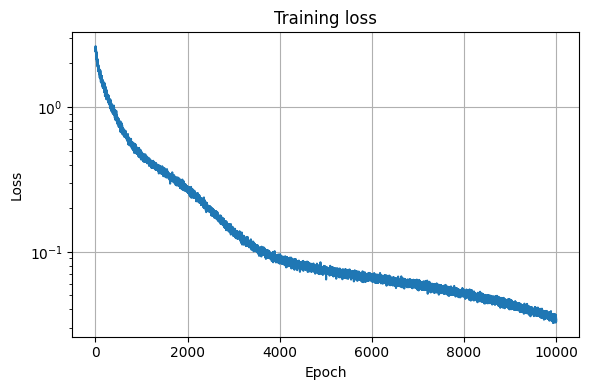

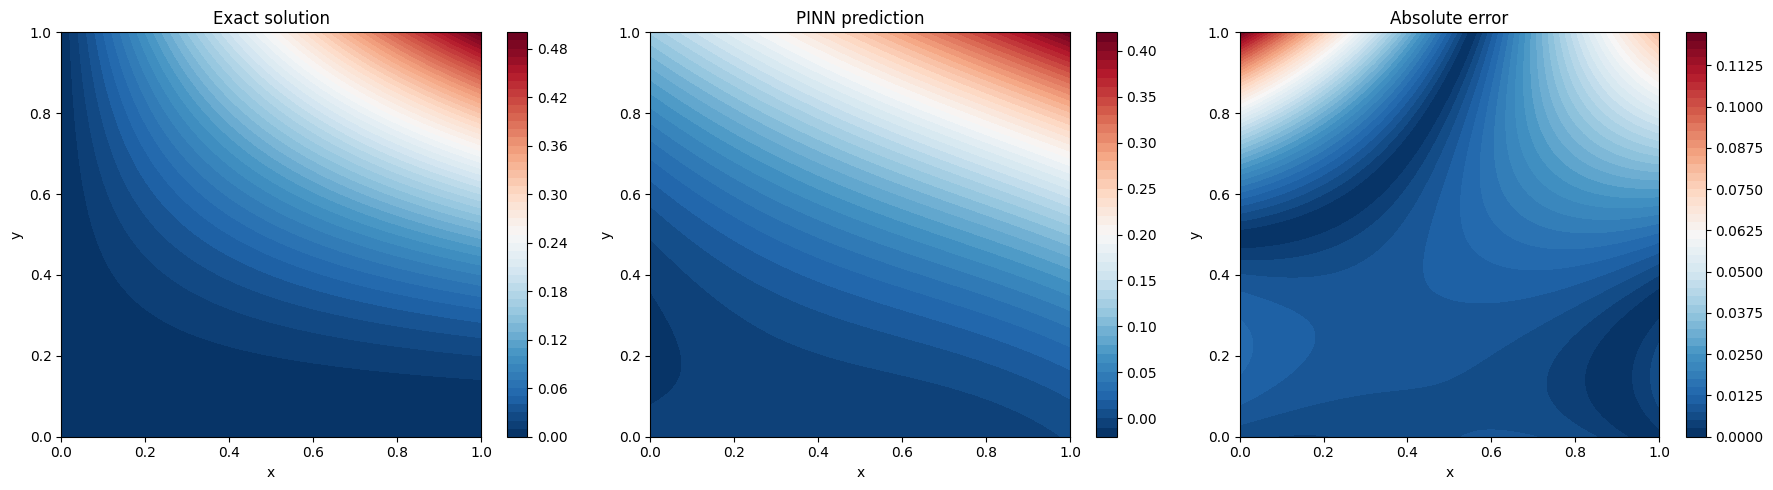

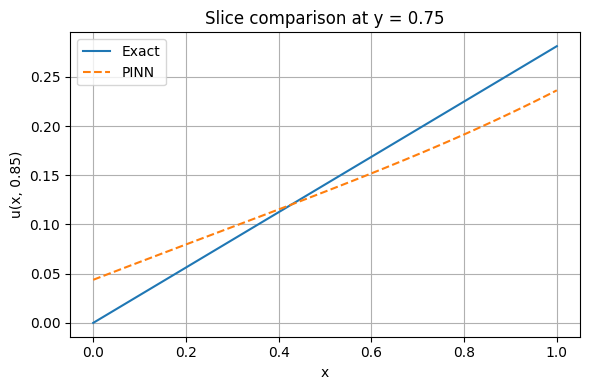

In [2]:
# =========================================================
# Visualization
# =========================================================
plt.figure(figsize=(6, 4))
plt.semilogy(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cp1 = plt.contourf(X, Y, u_exact, levels=50, cmap="RdBu_r")
plt.colorbar(cp1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exact solution")

plt.subplot(1, 3, 2)
cp2 = plt.contourf(X, Y, u_pred, levels=50, cmap="RdBu_r")
plt.colorbar(cp2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN prediction")

plt.subplot(1, 3, 3)
cp3 = plt.contourf(X, Y, abs_error, levels=50, cmap="RdBu_r")
plt.colorbar(cp3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Absolute error")

plt.tight_layout()
plt.show()

# =========================================================
# Optional: 1D slice comparison
# =========================================================
y_slice = 0.75 * np.ones_like(xv)
x_slice_t = torch.tensor(xv.reshape(-1, 1), dtype=torch.float32, device=device)
y_slice_t = torch.tensor(y_slice.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    u_slice_pred = model(x_slice_t, y_slice_t).cpu().numpy().flatten()

u_slice_exact = exact_u(xv, y_slice)

plt.figure(figsize=(6, 4))
plt.plot(xv, u_slice_exact, label="Exact")
plt.plot(xv, u_slice_pred, "--", label="PINN")
plt.xlabel("x")
plt.ylabel("u(x, 0.85)")
plt.title("Slice comparison at y = 0.75")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


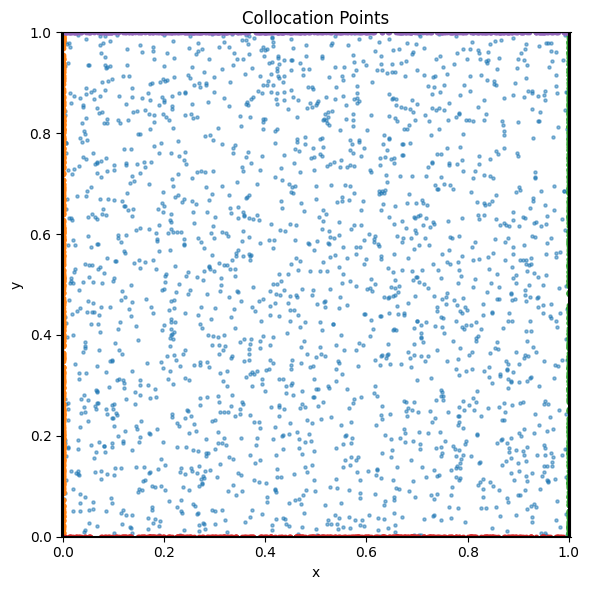

In [3]:
import matplotlib.pyplot as plt

# =========================================================
# Sample points
# =========================================================
n_int = 2000
n_bc = 400

# Interior
x_int, y_int = sample_interior(n_int)

# Boundaries
x_l, y_l = sample_boundary_left(n_bc)
x_r, y_r = sample_boundary_right(n_bc)
x_b, y_b = sample_boundary_bottom(n_bc)
x_t, y_t = sample_boundary_top(n_bc)

# Move to CPU for plotting
x_int, y_int = x_int.detach().cpu().numpy(), y_int.detach().cpu().numpy()
x_l, y_l = x_l.detach().cpu().numpy(), y_l.detach().cpu().numpy()
x_r, y_r = x_r.detach().cpu().numpy(), y_r.detach().cpu().numpy()
x_b, y_b = x_b.detach().cpu().numpy(), y_b.detach().cpu().numpy()
x_t, y_t = x_t.detach().cpu().numpy(), y_t.detach().cpu().numpy()

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(6, 6))

# Interior points
plt.scatter(x_int, y_int, s=5, alpha=0.5, label="Interior")

# Boundary points
plt.scatter(x_l, y_l, s=10, label="x=0 (Dirichlet)")
plt.scatter(x_r, y_r, s=10, label="x=1 (Dirichlet)")
plt.scatter(x_b, y_b, s=10, label="y=0 (Neumann)")
plt.scatter(x_t, y_t, s=10, label="y=1 (Neumann)")

# Domain box
plt.plot([0,1,1,0,0], [0,0,1,1,0], 'k-')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Collocation Points")
# plt.legend(loc="upper right", fontsize=8)
plt.axis("equal")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [4]:
import torch
from torch.optim import Optimizer


class TrustRegion(Optimizer):
    """
    Trust-region optimizer for small PyTorch models.

    Features:
    - Hessian approximation:
        * "full"     : explicit Hessian via Hessian-vector products
        * "identity" : B = I
        * "diag"     : diagonal Hessian approximation
    - Subproblem solver:
        * "dogleg"
        * "truncated_cg"

    Notes:
    - This is intended for small parameter dimensions.
    - Works best with full-batch closure.
    - Closure must return a scalar loss.
    """

    def __init__(
        self,
        params,
        lr=1.0,
        delta=1.0,
        delta_max=10.0,
        eta=1e-4,
        method="truncated_cg",
        hessian_approx="full",
        cg_tol=1e-6,
        cg_max_iter=None,
        damping=1e-6,
        verbose=False,
    ):
        defaults = dict(
            lr=lr,
            delta=delta,
            delta_max=delta_max,
            eta=eta,
            method=method,
            hessian_approx=hessian_approx,
            cg_tol=cg_tol,
            cg_max_iter=cg_max_iter,
            damping=damping,
            verbose=verbose,
        )
        super().__init__(params, defaults)

        if len(self.param_groups) != 1:
            raise ValueError("This optimizer currently supports exactly one parameter group.")

        self._params = self.param_groups[0]["params"]
        self.state["step"] = 0

    # =========================================================
    # Parameter utilities
    # =========================================================
    def _flatten_params(self):
        return torch.cat([p.detach().reshape(-1) for p in self._params])

    def _set_flat_params(self, flat_vector):
        offset = 0
        for p in self._params:
            numel = p.numel()
            p.data.copy_(flat_vector[offset:offset + numel].view_as(p))
            offset += numel

    def _flatten_tensors(self, tensors):
        return torch.cat([t.reshape(-1) for t in tensors])

    def _num_params(self):
        return sum(p.numel() for p in self._params)

    # =========================================================
    # Gradient and Hessian approximation
    # =========================================================
    def _compute_loss_and_grad(self, closure):
        loss = closure()
        grads = torch.autograd.grad(
            loss,
            self._params,
            create_graph=True,
            retain_graph=True,
            allow_unused=False,
        )
        g = self._flatten_tensors(grads)
        return loss, g, grads

    def _hvp_from_grad(self, grad_vec_tensors, v):
        """
        Hessian-vector product H v using autograd.
        grad_vec_tensors is the list of first derivatives with create_graph=True.
        """
        offset = 0
        v_list = []
        for p in self._params:
            numel = p.numel()
            v_list.append(v[offset:offset + numel].view_as(p))
            offset += numel

        hvp = torch.autograd.grad(
            grad_vec_tensors,
            self._params,
            grad_outputs=v_list,
            retain_graph=True,
            allow_unused=False,
        )
        return self._flatten_tensors(hvp)

    def _build_hessian(self, grad_vec_tensors, approx_type="full", damping=1e-6):
        n = self._num_params()
        device = self._params[0].device
        dtype = self._params[0].dtype

        if approx_type == "identity":
            return torch.eye(n, device=device, dtype=dtype)

        if approx_type == "diag":
            diag = torch.zeros(n, device=device, dtype=dtype)
            for i in range(n):
                e = torch.zeros(n, device=device, dtype=dtype)
                e[i] = 1.0
                hv = self._hvp_from_grad(grad_vec_tensors, e)
                diag[i] = hv[i]
            B = torch.diag(diag.clamp_min(damping))
            return B

        if approx_type == "full":
            cols = []
            for i in range(n):
                e = torch.zeros(n, device=device, dtype=dtype)
                e[i] = 1.0
                hv = self._hvp_from_grad(grad_vec_tensors, e)
                cols.append(hv.unsqueeze(1))
            H = torch.cat(cols, dim=1)

            # Symmetrize + damping
            H = 0.5 * (H + H.T)
            H = H + damping * torch.eye(n, device=device, dtype=dtype)
            return H

        raise ValueError(f"Unknown hessian_approx='{approx_type}'")

    # =========================================================
    # Trust-region subproblem helpers
    # =========================================================
    def _tau_to_boundary(self, p, d, delta):
        """
        Solve ||p + tau d|| = delta for tau >= 0.
        """
        a = torch.dot(d, d)
        b = 2.0 * torch.dot(p, d)
        c = torch.dot(p, p) - delta**2

        disc = b * b - 4.0 * a * c
        disc = torch.clamp(disc, min=0.0)
        sqrt_disc = torch.sqrt(disc)

        tau1 = (-b + sqrt_disc) / (2.0 * a)
        tau2 = (-b - sqrt_disc) / (2.0 * a)

        candidates = [tau for tau in [tau1, tau2] if tau >= 0]
        if len(candidates) == 0:
            return torch.tensor(0.0, device=p.device, dtype=p.dtype)
        return min(candidates)

    def _dogleg(self, g, B, delta):
        """
        Classical dogleg:
        - If B is not positive definite, fallback to Cauchy point
        - Otherwise use dogleg path between Cauchy point and Newton step
        """
        gBg = torch.dot(g, B @ g)

        # Cauchy point
        if gBg <= 1e-14:
            p_u = -(delta / (torch.norm(g) + 1e-14)) * g
        else:
            alpha_sd = torch.dot(g, g) / gBg
            p_u = -alpha_sd * g

        # Check positive definiteness by Cholesky
        try:
            L = torch.linalg.cholesky(B)
            p_b = -torch.cholesky_solve(g.unsqueeze(1), L).squeeze(1)
            pd_ok = True
        except RuntimeError:
            pd_ok = False

        # If not PD, fallback to Cauchy step
        if not pd_ok:
            if torch.norm(p_u) <= delta:
                return p_u
            return -(delta / (torch.norm(g) + 1e-14)) * g

        # If Newton step is inside trust region, take it
        if torch.norm(p_b) <= delta:
            return p_b

        # If Cauchy point is outside trust region, project it
        if torch.norm(p_u) >= delta:
            return -(delta / (torch.norm(g) + 1e-14)) * g

        # Otherwise interpolate along dogleg path
        d = p_b - p_u
        tau = self._tau_to_boundary(p_u, d, delta)
        return p_u + tau * d

    def _truncated_cg(self, g, B, delta, tol=1e-6, max_iter=None):
        """
        Steihaug-Toint truncated CG.
        Solves approximately:
            min  g^T p + 1/2 p^T B p   s.t. ||p|| <= delta
        """
        n = g.numel()
        if max_iter is None:
            max_iter = n

        p = torch.zeros_like(g)
        r = g.clone()
        d = -r

        if torch.norm(r) < tol:
            return p

        for _ in range(max_iter):
            Bd = B @ d
            dBd = torch.dot(d, Bd)

            # Negative curvature
            if dBd <= 1e-14:
                tau = self._tau_to_boundary(p, d, delta)
                return p + tau * d

            rr = torch.dot(r, r)
            alpha = rr / dBd
            p_next = p + alpha * d

            # Hit trust-region boundary
            if torch.norm(p_next) >= delta:
                tau = self._tau_to_boundary(p, d, delta)
                return p + tau * d

            r_next = r + alpha * Bd

            if torch.norm(r_next) < tol:
                return p_next

            beta = torch.dot(r_next, r_next) / rr
            d = -r_next + beta * d
            p = p_next
            r = r_next

        return p

    def _solve_subproblem(self, g, B, delta, method, cg_tol, cg_max_iter):
        if method == "dogleg":
            return self._dogleg(g, B, delta)
        elif method == "truncated_cg":
            return self._truncated_cg(g, B, delta, tol=cg_tol, max_iter=cg_max_iter)
        else:
            raise ValueError(f"Unknown method='{method}'")

    def _quadratic_model(self, loss_val, g, B, p):
        return loss_val + torch.dot(g, p) + 0.5 * torch.dot(p, B @ p)

    # =========================================================
    # Main step
    # =========================================================
    @torch.no_grad()
    def _accept_step(self, x_old, p):
        self._set_flat_params(x_old + p)

    @torch.no_grad()
    def _reject_step(self, x_old):
        self._set_flat_params(x_old)

    def step(self, closure):
        """
        closure():
            optimizer.zero_grad()
            loss = ...
            return loss
        """
        if closure is None:
            raise ValueError("TrustRegion requires a closure.")

        group = self.param_groups[0]
        delta = group["delta"]
        delta_max = group["delta_max"]
        eta = group["eta"]
        method = group["method"]
        hessian_approx = group["hessian_approx"]
        cg_tol = group["cg_tol"]
        cg_max_iter = group["cg_max_iter"]
        damping = group["damping"]
        verbose = group["verbose"]

        # We need gradients with graph for Hessian/HVP
        with torch.enable_grad():
            x_old = self._flatten_params().clone()

            loss, g, grad_tensors = self._compute_loss_and_grad(closure)
            loss_val = loss.detach()

            B = self._build_hessian(
                grad_tensors,
                approx_type=hessian_approx,
                damping=damping,
            )

            p = self._solve_subproblem(
                g=g.detach(),
                B=B.detach(),
                delta=delta,
                method=method,
                cg_tol=cg_tol,
                cg_max_iter=cg_max_iter,
            )

            # Predicted reduction
            m0 = loss_val
            mp = self._quadratic_model(loss_val, g.detach(), B.detach(), p.detach())
            pred_red = (m0 - mp).item()

            # Trial step
            self._accept_step(x_old, p)

            trial_loss = closure()
            ared = (loss_val - trial_loss.detach()).item()

            # Ratio
            if abs(pred_red) < 1e-14:
                rho = -float("inf")
            else:
                rho = ared / pred_red

            # Update radius
            p_norm = torch.norm(p).item()
            if rho < 0.25:
                delta = 0.25 * delta
            elif rho > 0.75 and abs(p_norm - delta) < 1e-8:
                delta = min(2.0 * delta, delta_max)

            # Accept / reject
            if rho > eta:
                accepted = True
                final_loss = trial_loss.detach()
            else:
                accepted = False
                self._reject_step(x_old)
                final_loss = loss_val

            group["delta"] = delta
            self.state["step"] += 1

            if verbose:
                print(
                    f"[TR] step={self.state['step']:4d} "
                    f"loss={loss_val.item():.6e} "
                    # f"trial={trial_loss.item():.6e} "
                    f"ared={ared:.3e} pred={pred_red:.3e} "
                    f"rho={rho:.3e} delta={delta:.3e} "
                    f"accepted={accepted}"
                )

            return final_loss


In [15]:
def compute_loss(model, data):
    x_int, y_int = data["int"]
    x_l, y_l = data["left"]
    x_r, y_r = data["right"]
    x_b, y_b = data["bottom"]
    x_t, y_t = data["top"]

    # Interior
    res = pde_residual(model, x_int, y_int)
    loss_pde = torch.mean(res**2)

    # Dirichlet: x = 0
    u_l = model(x_l, y_l)
    loss_left = torch.mean((u_l - 0.0)**2)

    # Dirichlet: x = 1
    u_r = model(x_r, y_r)
    target_r = 0.5 * y_r**2
    loss_right = torch.mean((u_r - target_r)**2)

    # Bottom Neumann
    u_b = model(x_b, y_b)
    u_y_b = torch.autograd.grad(
        u_b, y_b, grad_outputs=torch.ones_like(u_b), create_graph=True
    )[0]
    flux_bottom = kappa(x_b, y_b) * u_y_b
    loss_bottom = torch.mean((flux_bottom - 0.0)**2)

    # Top Neumann
    u_t = model(x_t, y_t)
    u_y_t = torch.autograd.grad(
        u_t, y_t, grad_outputs=torch.ones_like(u_t), create_graph=True
    )[0]
    flux_top = -kappa(x_t, y_t) * u_y_t
    target_top = -2.0 * x_t**2
    loss_top = torch.mean((flux_top - target_top)**2)

    total_loss = loss_pde + loss_left + loss_right + loss_bottom + loss_top

    return total_loss, {
        "pde": loss_pde.item(),
        "left": loss_left.item(),
        "right": loss_right.item(),
        "bottom": loss_bottom.item(),
        "top": loss_top.item(),
    }

model = PINN().to(device)
# =========================================================
# Training
# =========================================================
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = TrustRegion(
    model.parameters(),
    delta=1.0,
    delta_max=5.0,
    eta=1e-4,
    method="dogleg",     # "dogleg" or "truncated_cg"
    hessian_approx="diag",     # "full", "diag", or "identity"
    cg_tol=1e-6,
    cg_max_iter=100,
    damping=1e-4,
    verbose=False,
)
epochs = 200
history = {
    "epoch": [],
    "total": [],
    "pde": [],
    "left": [],
    "right": [],
    "bottom": [],
    "top": [],
}

for epoch in range(epochs):
    # resample ONCE for this epoch / optimizer step
    data = {
        "int": sample_interior(2000),
        "left": sample_boundary_left(400),
        "right": sample_boundary_right(400),
        "bottom": sample_boundary_bottom(400),
        "top": sample_boundary_top(400),
    }

    def closure():
        optimizer.zero_grad()
        loss, parts = compute_loss(model, data)
        return loss

    loss = optimizer.step(closure)

    loss_val, parts = compute_loss(model, data)

    history["epoch"].append(epoch)
    history["total"].append(loss_val.item())
    history["pde"].append(parts["pde"])
    history["left"].append(parts["left"])
    history["right"].append(parts["right"])
    history["bottom"].append(parts["bottom"])
    history["top"].append(parts["top"])

    if epoch % 20 == 0:
        # with torch.no_grad():
        
        print(
            f"Epoch {epoch:5d} | Loss = {loss_val.item():.6e} | "
            f"PDE = {parts['pde']:.2e} | "
            f"L = {parts['left']:.2e} | "
            f"R = {parts['right']:.2e} | "
            f"B = {parts['bottom']:.2e} | "
            f"T = {parts['top']:.2e}"
        )

# =========================================================
# Evaluation on grid
# =========================================================
N = 101
xv = np.linspace(0, 1, N)
yv = np.linspace(0, 1, N)
X, Y = np.meshgrid(xv, yv)

XY = np.stack([X.flatten(), Y.flatten()], axis=1)
x_test = torch.tensor(XY[:, 0:1], dtype=torch.float32, device=device)
y_test = torch.tensor(XY[:, 1:2], dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred = model(x_test, y_test).cpu().numpy().reshape(N, N)

u_exact = exact_u(X, Y)
abs_error = np.abs(u_pred - u_exact)

l2_error = np.sqrt(np.mean((u_pred - u_exact)**2))
linf_error = np.max(abs_error)

print("\nError with exact solution")
print(f"L2 error   = {l2_error:.6e}")
print(f"Linf error = {linf_error:.6e}")

Epoch     0 | Loss = 1.568574e+00 | PDE = 7.11e-01 | L = 6.76e-03 | R = 2.34e-01 | B = 2.39e-02 | T = 5.93e-01
Epoch    20 | Loss = 2.901104e-01 | PDE = 1.73e-01 | L = 9.42e-03 | R = 1.64e-03 | B = 2.70e-02 | T = 7.93e-02
Epoch    40 | Loss = 1.628599e-01 | PDE = 9.40e-02 | L = 7.71e-03 | R = 4.10e-03 | B = 4.46e-03 | T = 5.26e-02
Epoch    60 | Loss = 8.622012e-02 | PDE = 4.50e-02 | L = 6.22e-03 | R = 2.39e-03 | B = 2.13e-03 | T = 3.05e-02
Epoch    80 | Loss = 7.239671e-02 | PDE = 3.49e-02 | L = 4.73e-03 | R = 2.03e-03 | B = 1.71e-03 | T = 2.90e-02
Epoch   100 | Loss = 6.417405e-02 | PDE = 3.49e-02 | L = 4.05e-03 | R = 1.52e-03 | B = 1.47e-03 | T = 2.23e-02
Epoch   120 | Loss = 6.066430e-02 | PDE = 3.11e-02 | L = 3.51e-03 | R = 2.26e-03 | B = 1.72e-03 | T = 2.21e-02
Epoch   140 | Loss = 6.107110e-02 | PDE = 2.94e-02 | L = 2.81e-03 | R = 2.23e-03 | B = 2.00e-03 | T = 2.46e-02
Epoch   160 | Loss = 5.532606e-02 | PDE = 2.75e-02 | L = 3.17e-03 | R = 2.25e-03 | B = 1.52e-03 | T = 2.09e-02
E

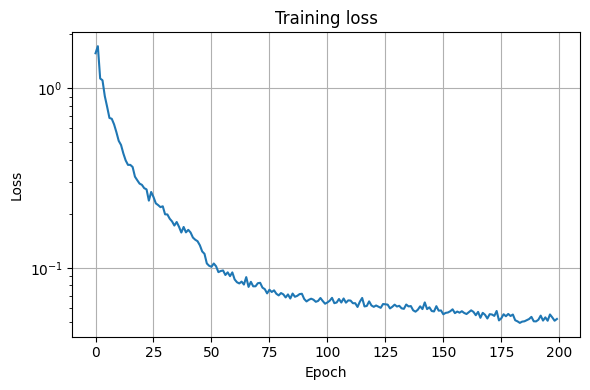

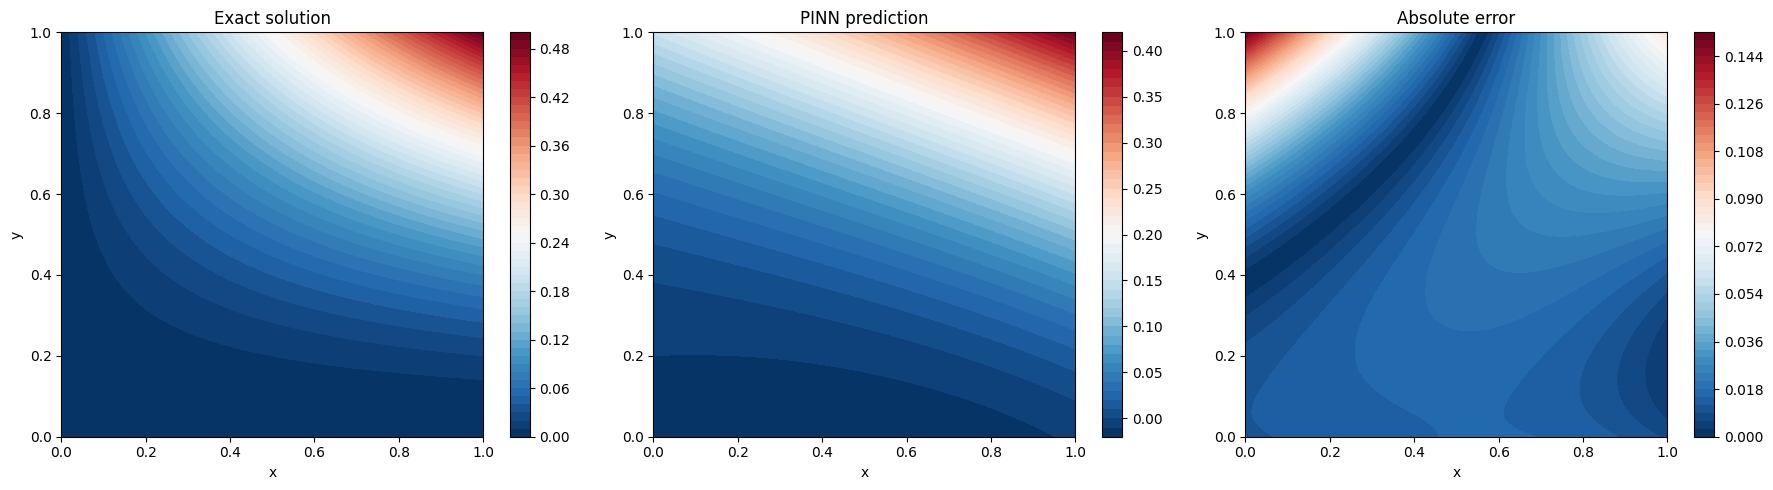

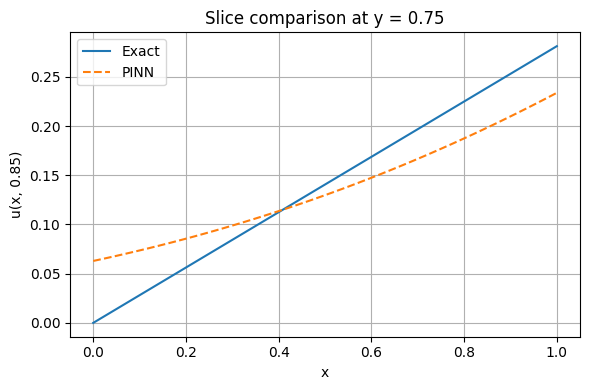

In [16]:
# =========================================================
# Visualization
# =========================================================
plt.figure(figsize=(6, 4))
plt.semilogy(history["total"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cp1 = plt.contourf(X, Y, u_exact, levels=50, cmap="RdBu_r")
plt.colorbar(cp1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exact solution")

plt.subplot(1, 3, 2)
cp2 = plt.contourf(X, Y, u_pred, levels=50, cmap="RdBu_r")
plt.colorbar(cp2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN prediction")

plt.subplot(1, 3, 3)
cp3 = plt.contourf(X, Y, abs_error, levels=50, cmap="RdBu_r")
plt.colorbar(cp3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Absolute error")

plt.tight_layout()
plt.show()

# =========================================================
# Optional: 1D slice comparison
# =========================================================
y_slice = 0.75 * np.ones_like(xv)
x_slice_t = torch.tensor(xv.reshape(-1, 1), dtype=torch.float32, device=device)
y_slice_t = torch.tensor(y_slice.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    u_slice_pred = model(x_slice_t, y_slice_t).cpu().numpy().flatten()

u_slice_exact = exact_u(xv, y_slice)

plt.figure(figsize=(6, 4))
plt.plot(xv, u_slice_exact, label="Exact")
plt.plot(xv, u_slice_pred, "--", label="PINN")
plt.xlabel("x")
plt.ylabel("u(x, 0.85)")
plt.title("Slice comparison at y = 0.75")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
import torch
from torch.optim import Optimizer


class TadamTrustRegion(Optimizer):
    """
    Full-batch Tadam-style trust-region optimizer for PINNs / general non-MLE losses.

    Key changes from the original TrustRegion class:
    - Replaces Hessian / Hessian-vector-product machinery with the paper's
      diagonal-plus-rank-one empirical Fisher / Gauss-Newton-type approximation
    - Uses per-point (or per-term) gradients g_k
    - Uses the Tadam-style clipped Fisher-scaled step
    - Uses trust-region ratio rho to expand / shrink delta

    IMPORTANT CLOSURE CONTRACT
    --------------------------
    The closure must return either:

    1) a dict with:
        {
            "loss": scalar_total_loss,
            "point_losses": 1D tensor of weighted per-point / per-term contributions
        }

       where:
         scalar_total_loss == point_losses.mean()   OR   point_losses.sum()
       as long as it is consistent with how you want g := grad(loss).

    OR

    2) a tuple:
        (scalar_total_loss, point_losses)

    Notes:
    - `point_losses` should already include the PINN weights lambda_r, lambda_b, lambda_i
      if you want the curvature/statistics to reflect the true total loss.
    - This implementation is intended for small models, because it computes one gradient
      per point / term.
    """

    def __init__(
        self,
        params,
        lr=1.0,
        delta=1.0,
        delta_max=10.0,
        gamma=0.25,
        c_down=0.25,
        c_up=2.0,
        eps=1e-8,
        accept_threshold=1e-4,
        verbose=False,
    ):
        defaults = dict(
            lr=lr,
            delta=delta,
            delta_max=delta_max,
            gamma=gamma,
            c_down=c_down,
            c_up=c_up,
            eps=eps,
            accept_threshold=accept_threshold,
            verbose=verbose,
        )
        super().__init__(params, defaults)

        if len(self.param_groups) != 1:
            raise ValueError("This optimizer currently supports exactly one parameter group.")

        self._params = self.param_groups[0]["params"]
        self.state["step"] = 0

    # =========================================================
    # Parameter utilities
    # =========================================================
    def _flatten_params(self):
        return torch.cat([p.detach().reshape(-1) for p in self._params])

    def _set_flat_params(self, flat_vector):
        offset = 0
        for p in self._params:
            numel = p.numel()
            p.data.copy_(flat_vector[offset:offset + numel].view_as(p))
            offset += numel

    def _flatten_tensors(self, tensors):
        return torch.cat([t.reshape(-1) for t in tensors])

    def _num_params(self):
        return sum(p.numel() for p in self._params)

    # =========================================================
    # Loss / gradient helpers
    # =========================================================
    def _parse_closure_output(self, closure_out):
        if isinstance(closure_out, dict):
            loss = closure_out["loss"]
            point_losses = closure_out["point_losses"]
            return loss, point_losses

        if isinstance(closure_out, tuple) and len(closure_out) == 2:
            loss, point_losses = closure_out
            return loss, point_losses

        raise ValueError(
            "Closure must return either {'loss': scalar, 'point_losses': 1D tensor} "
            "or (loss, point_losses)."
        )

    def _compute_loss_and_point_grads(self, closure):
        closure_out = closure()
        loss, point_losses = self._parse_closure_output(closure_out)

        if loss.ndim != 0:
            raise ValueError("closure()['loss'] must be a scalar tensor.")

        point_losses = point_losses.reshape(-1)
        N = point_losses.numel()
        if N == 0:
            raise ValueError("point_losses must contain at least one entry.")

        # Mean gradient of total loss
        grads = torch.autograd.grad(
            loss,
            self._params,
            create_graph=False,
            retain_graph=True,
            allow_unused=False,
        )
        g = self._flatten_tensors(grads).detach()

        # Per-point (or per-term) gradients g_k
        gk_list = []
        for k in range(N):
            grads_k = torch.autograd.grad(
                point_losses[k],
                self._params,
                create_graph=False,
                retain_graph=True,
                allow_unused=False,
            )
            gk = self._flatten_tensors(grads_k).detach()
            gk_list.append(gk)

        G = torch.stack(gk_list, dim=0)  # [N, P]
        return loss, point_losses, g, G

    # =========================================================
    # Tadam statistics / step
    # =========================================================
    def _compute_tadam_stats(self, g, G, eps):
        """
        G : [N, P] stacked per-point gradients
        g : [P]    full-batch mean gradient

        Returns:
            v        : [P] componentwise variance
            g2_bar   : [P] second moment E[g_k^2]
            f        : [P] diagonal vector from Sherman-Morrison reduction
        """
        g2_bar = (G * G).mean(dim=0)                 # E[g_k^2]
        v = ((G - g.unsqueeze(0)) ** 2).mean(dim=0) # Var[g_k]

        v_safe = v + eps
        scalar = 1.0 + torch.dot(g / v_safe, g)
        f = scalar * v_safe
        return v, g2_bar, f

    def _compute_step(self, g, f, g2_bar, delta, lr, eps):
        """
        Tadam-style clipped Fisher-scaled step:
            t = min(f^{-1}, delta / sqrt(g2_bar + eps))
            d = - t ⊙ g
            p = lr * d
        """
        fisher_scale = 1.0 / (f + eps)
        trust_clip = delta / torch.sqrt(g2_bar + eps)
        t = torch.minimum(fisher_scale, trust_clip)
        d = -t * g
        p = lr * d
        return p, t, d

    def _model_value(self, loss_val, g, v, p, lr, eps):
        """
        m(p) = L(theta) + g^T p + (1 / (2 lr)) p^T Fhat p
        where Fhat = g g^T + diag(v)

        Using:
            p^T Fhat p = (g^T p)^2 + sum_i v_i p_i^2
        """
        gp = torch.dot(g, p)
        quad = gp * gp + torch.dot(v, p * p)
        return loss_val + gp + 0.5 * quad / max(lr, eps)

    # =========================================================
    # Accept / reject
    # =========================================================
    @torch.no_grad()
    def _accept_step(self, x_old, p):
        self._set_flat_params(x_old + p)

    @torch.no_grad()
    def _reject_step(self, x_old):
        self._set_flat_params(x_old)

    # =========================================================
    # Main step
    # =========================================================
    def step(self, closure):
        """
        closure():
            optimizer.zero_grad(set_to_none=True)
            total_loss, point_losses = ...
            return {"loss": total_loss, "point_losses": point_losses}

        Example PINN closure:
            def closure():
                optimizer.zero_grad(set_to_none=True)

                Lr_vec = lambda_r * residuals.pow(2).reshape(-1)
                Lb_vec = lambda_b * bc_errors.pow(2).reshape(-1)
                Li_vec = lambda_i * ic_errors.pow(2).reshape(-1)

                point_losses = torch.cat([Lr_vec, Lb_vec, Li_vec], dim=0)
                loss = point_losses.mean()

                return {"loss": loss, "point_losses": point_losses}
        """
        if closure is None:
            raise ValueError("TadamTrustRegion requires a closure.")

        group = self.param_groups[0]
        lr = group["lr"]
        delta = group["delta"]
        delta_max = group["delta_max"]
        gamma = group["gamma"]
        c_down = group["c_down"]
        c_up = group["c_up"]
        eps = group["eps"]
        accept_threshold = group["accept_threshold"]
        verbose = group["verbose"]

        with torch.enable_grad():
            x_old = self._flatten_params().clone()

            loss, point_losses, g, G = self._compute_loss_and_point_grads(closure)
            loss_val = loss.detach()

            v, g2_bar, f = self._compute_tadam_stats(g, G, eps=eps)
            p, t, d = self._compute_step(g, f, g2_bar, delta=delta, lr=lr, eps=eps)

            # Predicted reduction
            m0 = loss_val
            mp = self._model_value(loss_val, g, v, p, lr=lr, eps=eps)
            pred_red = (m0 - mp).item()

            # Trial step
            self._accept_step(x_old, p)

            with torch.enable_grad():
                trial_out = closure()
                trial_loss, _ = self._parse_closure_output(trial_out)

            trial_loss_val = trial_loss.detach()
            ared = (loss_val - trial_loss_val).item()

            # Ratio
            if abs(pred_red) < 1e-14:
                rho = -float("inf")
            else:
                rho = ared / pred_red

            # Trust-region radius update
            if rho < gamma:
                delta = c_down * delta
            elif rho > 1.0 - gamma:
                delta = min(c_up * delta, delta_max)

            # Accept / reject
            if rho > accept_threshold:
                accepted = True
                final_loss = trial_loss_val
            else:
                accepted = False
                self._reject_step(x_old)
                final_loss = loss_val

            group["delta"] = delta
            self.state["step"] += 1

            if verbose:
                print(
                    f"[Tadam-TR] step={self.state['step']:4d} "
                    f"loss={loss_val.item():.6e} "
                    f"ared={ared:.3e} pred={pred_red:.3e} "
                    f"rho={rho:.3e} delta={delta:.3e} "
                    f"||g||={torch.norm(g).item():.3e} "
                    f"accepted={accepted}"
                )

            return final_loss

In [6]:
def compute_loss(model, data, return_pointwise=False):
    x_int, y_int = data["int"]
    x_l, y_l = data["left"]
    x_r, y_r = data["right"]
    x_b, y_b = data["bottom"]
    x_t, y_t = data["top"]

    # Interior
    res = pde_residual(model, x_int, y_int)
    pde_vec = (res**2).reshape(-1)
    loss_pde = torch.mean(pde_vec)

    # Dirichlet: x = 0
    u_l = model(x_l, y_l)
    left_vec = ((u_l - 0.0)**2).reshape(-1)
    loss_left = torch.mean(left_vec)

    # Dirichlet: x = 1
    u_r = model(x_r, y_r)
    target_r = 0.5 * y_r**2
    right_vec = ((u_r - target_r)**2).reshape(-1)
    loss_right = torch.mean(right_vec)

    # Bottom Neumann
    u_b = model(x_b, y_b)
    u_y_b = torch.autograd.grad(
        u_b, y_b, grad_outputs=torch.ones_like(u_b), create_graph=True
    )[0]
    flux_bottom = kappa(x_b, y_b) * u_y_b
    bottom_vec = ((flux_bottom - 0.0)**2).reshape(-1)
    loss_bottom = torch.mean(bottom_vec)

    # Top Neumann
    u_t = model(x_t, y_t)
    u_y_t = torch.autograd.grad(
        u_t, y_t, grad_outputs=torch.ones_like(u_t), create_graph=True
    )[0]
    flux_top = -kappa(x_t, y_t) * u_y_t
    target_top = -2.0 * x_t**2
    top_vec = ((flux_top - target_top)**2).reshape(-1)
    loss_top = torch.mean(top_vec)

    total_loss = loss_pde + loss_left + loss_right + loss_bottom + loss_top

    parts = {
        "pde": loss_pde.item(),
        "left": loss_left.item(),
        "right": loss_right.item(),
        "bottom": loss_bottom.item(),
        "top": loss_top.item(),
    }

    if return_pointwise:
        point_losses = torch.cat([pde_vec, left_vec, right_vec, bottom_vec, top_vec], dim=0)
        return total_loss, parts, point_losses

    return total_loss, parts

In [7]:
model = PINN().to(device)
# =========================================================
# Training
# =========================================================
optimizer = TadamTrustRegion(
    model.parameters(),
    lr=1.0,              # step multiplier
    delta=1.0,
    delta_max=5.0,
    gamma=0.25,
    c_down=0.25,
    c_up=2.0,
    eps=1e-8,
    accept_threshold=1e-4,
    verbose=False,
)

epochs = 200
history = {
    "epoch": [],
    "total": [],
    "pde": [],
    "left": [],
    "right": [],
    "bottom": [],
    "top": [],
}

for epoch in range(epochs):
    data = {
        "int": sample_interior(2000),
        "left": sample_boundary_left(400),
        "right": sample_boundary_right(400),
        "bottom": sample_boundary_bottom(400),
        "top": sample_boundary_top(400),
    }

    def closure():
        optimizer.zero_grad(set_to_none=True)

        # You need a version of compute_loss that also returns per-point losses
        loss, parts, point_losses = compute_loss(model, data, return_pointwise=True)

        return {
            "loss": loss,
            "point_losses": point_losses,
        }

    loss = optimizer.step(closure)

    loss_val, parts = compute_loss(model, data)

    history["epoch"].append(epoch)
    history["total"].append(loss_val.item())
    history["pde"].append(parts["pde"])
    history["left"].append(parts["left"])
    history["right"].append(parts["right"])
    history["bottom"].append(parts["bottom"])
    history["top"].append(parts["top"])

    if epoch % 20 == 0:
        # with torch.no_grad():
        
        print(
            f"Epoch {epoch:5d} | Loss = {loss_val.item():.6e} | "
            f"PDE = {parts['pde']:.2e} | "
            f"L = {parts['left']:.2e} | "
            f"R = {parts['right']:.2e} | "
            f"B = {parts['bottom']:.2e} | "
            f"T = {parts['top']:.2e}"
        )

# =========================================================
# Evaluation on grid
# =========================================================
N = 101
xv = np.linspace(0, 1, N)
yv = np.linspace(0, 1, N)
X, Y = np.meshgrid(xv, yv)

XY = np.stack([X.flatten(), Y.flatten()], axis=1)
x_test = torch.tensor(XY[:, 0:1], dtype=torch.float32, device=device)
y_test = torch.tensor(XY[:, 1:2], dtype=torch.float32, device=device)

with torch.no_grad():
    u_pred = model(x_test, y_test).cpu().numpy().reshape(N, N)

u_exact = exact_u(X, Y)
abs_error = np.abs(u_pred - u_exact)

l2_error = np.sqrt(np.mean((u_pred - u_exact)**2))
linf_error = np.max(abs_error)

print("\nError with exact solution")
print(f"L2 error   = {l2_error:.6e}")
print(f"Linf error = {linf_error:.6e}")

Epoch     0 | Loss = 2.220398e+00 | PDE = 1.40e+00 | L = 5.03e-02 | R = 1.64e-01 | B = 2.64e-03 | T = 6.08e-01
Epoch    20 | Loss = 9.877141e-02 | PDE = 5.20e-02 | L = 5.46e-03 | R = 1.87e-03 | B = 3.54e-03 | T = 3.59e-02
Epoch    40 | Loss = 6.890876e-02 | PDE = 3.64e-02 | L = 3.71e-03 | R = 1.56e-03 | B = 3.62e-03 | T = 2.36e-02
Epoch    60 | Loss = 5.096764e-02 | PDE = 2.33e-02 | L = 2.94e-03 | R = 1.75e-03 | B = 1.79e-03 | T = 2.12e-02
Epoch    80 | Loss = 3.725392e-02 | PDE = 1.71e-02 | L = 1.97e-03 | R = 1.50e-03 | B = 1.59e-03 | T = 1.51e-02
Epoch   100 | Loss = 3.063875e-02 | PDE = 1.50e-02 | L = 1.89e-03 | R = 1.30e-03 | B = 1.44e-03 | T = 1.10e-02
Epoch   120 | Loss = 2.249347e-02 | PDE = 9.66e-03 | L = 1.57e-03 | R = 7.71e-04 | B = 1.44e-03 | T = 9.05e-03
Epoch   140 | Loss = 1.685409e-02 | PDE = 7.28e-03 | L = 1.01e-03 | R = 4.82e-04 | B = 1.37e-03 | T = 6.71e-03
Epoch   160 | Loss = 1.255654e-02 | PDE = 4.81e-03 | L = 7.82e-04 | R = 3.67e-04 | B = 1.36e-03 | T = 5.23e-03
E

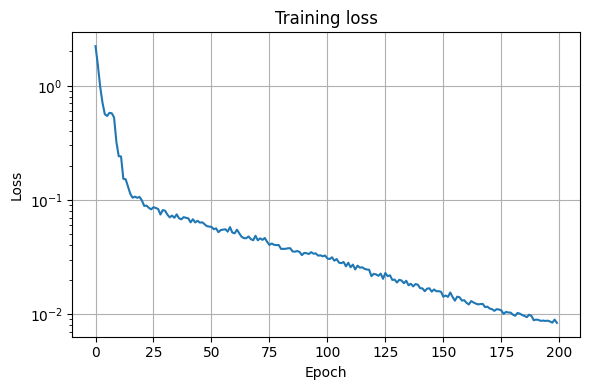

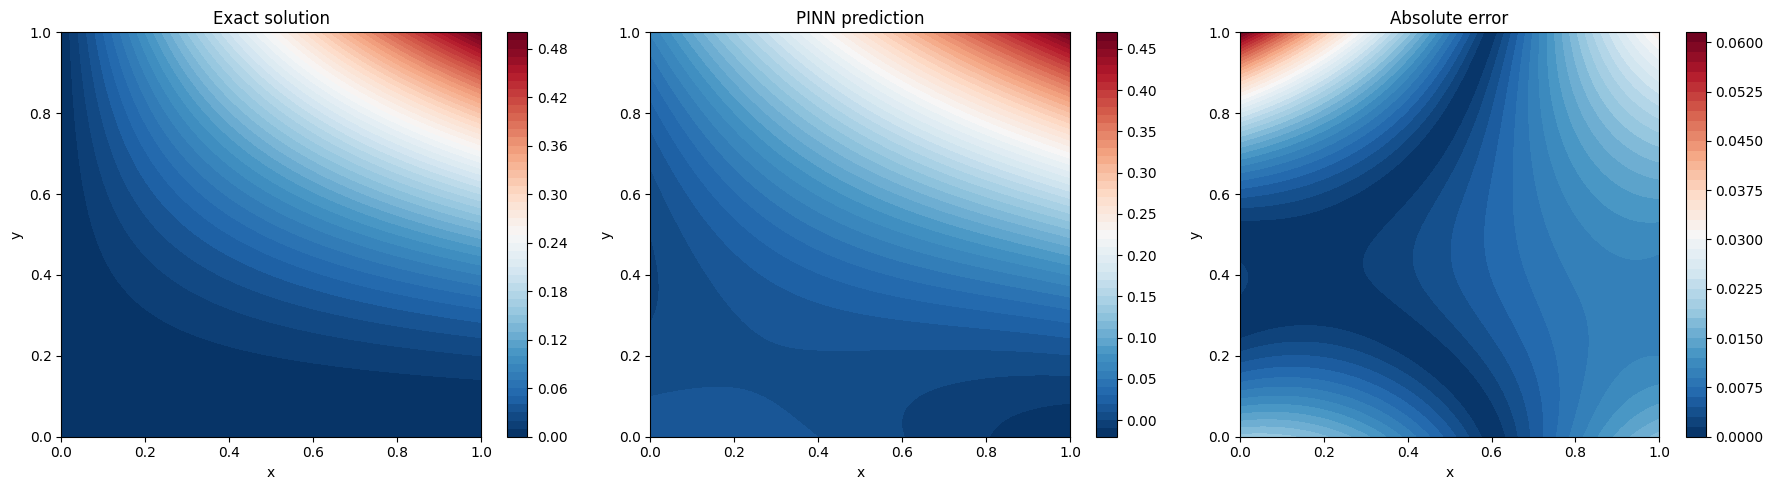

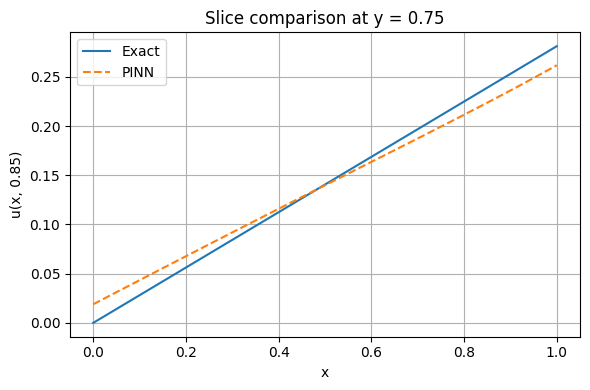

In [8]:
# =========================================================
# Visualization
# =========================================================
plt.figure(figsize=(6, 4))
plt.semilogy(history["total"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cp1 = plt.contourf(X, Y, u_exact, levels=50, cmap="RdBu_r")
plt.colorbar(cp1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exact solution")

plt.subplot(1, 3, 2)
cp2 = plt.contourf(X, Y, u_pred, levels=50, cmap="RdBu_r")
plt.colorbar(cp2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN prediction")

plt.subplot(1, 3, 3)
cp3 = plt.contourf(X, Y, abs_error, levels=50, cmap="RdBu_r")
plt.colorbar(cp3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Absolute error")

plt.tight_layout()
plt.show()

# =========================================================
# Optional: 1D slice comparison
# =========================================================
y_slice = 0.75 * np.ones_like(xv)
x_slice_t = torch.tensor(xv.reshape(-1, 1), dtype=torch.float32, device=device)
y_slice_t = torch.tensor(y_slice.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    u_slice_pred = model(x_slice_t, y_slice_t).cpu().numpy().flatten()

u_slice_exact = exact_u(xv, y_slice)

plt.figure(figsize=(6, 4))
plt.plot(xv, u_slice_exact, label="Exact")
plt.plot(xv, u_slice_pred, "--", label="PINN")
plt.xlabel("x")
plt.ylabel("u(x, 0.85)")
plt.title("Slice comparison at y = 0.75")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()